# 💉 VaccineNLP · PhoBERT-v2 Multitask Classifier
## Phát hiện Tin giả Vắc-xin & Phân tích Thái độ Cộng đồng (Tiếng Việt)

**Tác giả:** Kim Mạnh Hưng (2211090016) · Đinh Lê Quỳnh Phương (2211090031)  
**Người hướng dẫn:** TS. Trần Lâm Quân  
**Trường:** Đại học Y tế Công cộng (HUPH)  
**Môi trường:** Kaggle · GPU T4 x2  

---

### Tổng quan kiến trúc

Notebook này huấn luyện **Động cơ Phân loại** (Discriminator) trong kiến trúc **Dual-Student Hybrid** của dự án VaccineNLP.
Mô hình sử dụng **PhoBERT-base-v2** (`vinai/phobert-base-v2`) — pretrained encoder tiếng Việt mạnh nhất hiện tại — 
kết hợp với **Multi-task Learning** để dự đoán đồng thời 3 trục phân loại:

| Task | Nhãn | Lý do quan trọng |
|---|---|---|
| **Misinformation** | Tin giả / Chính xác | Mục tiêu chính của đề tài |
| **Stance** | Ủng hộ / Phản đối / Trung lập | 3 nhãn chuẩn — Fallback Bucket cho edge cases |
| **Sentiment** | Tiêu cực / Trung tính / Tích cực | Hỗ trợ phân tích thái độ cộng đồng |

### Các quyết định thiết kế then chốt

- **Weighted CrossEntropyLoss**: Bắt buộc do mất cân bằng nhãn nghiêm trọng (class imbalance). Nhãn *Tin giả* chỉ chiếm ~15% corpus.
- **Multi-task Learning (3 heads)**: Chia sẻ encoder giúp regularization tự nhiên, tránh overfitting trên tập nhỏ.
- **Word Segmentation (underthesea)**: PhoBERT yêu cầu văn bản được tách từ tiếng Việt trước khi tokenize.
- **Early Stopping + OneCycleLR**: Tối ưu cho fine-tuning BERT trên GPU đơn.

```
Input Text (đã tách từ)
      ↓
  [PhoBERT Encoder - 110M params]
      ↓
  [CLS] pooler_output (768-dim)
      ↓           ↓           ↓
 Head: Misinfo  Head: Stance  Head: Sentiment
  (2 classes)   (3 classes)   (3 classes)
```

## ⚡ Quick Start — Cấu hình Trước Khi Chạy

> **Chỉ cần sửa 2 dòng dưới đây**, toàn bộ notebook sẽ chạy đúng.

### Bước 1 · Thêm Dataset vào Notebook
Trong Kaggle sidebar → **+ Add Data** → tìm dataset của bạn → Add.  
Sau khi add, đường dẫn sẽ có dạng: `/kaggle/input/<tên-dataset>/...`

### Bước 2 · Cập nhật Paths (Cell Section 3)
```python
TRAIN_PATH = "/kaggle/input/vaccinenlp-clean-data/05_model_ready/train_v2_seg_v3.jsonl"
TEST_PATH  = "/kaggle/input/vaccinenlp-clean-data/03_processed/benchmark_test_set_v3.jsonl"
```

### Bước 3 · Bật GPU
Kaggle sidebar → **Session options** → Accelerator → **GPU T4 x2** → Save.

### Bước 4 · Chạy All
**Run All** (Shift+Enter từng cell, hoặc menu **Run > Run All Cells**).

---

### Cấu trúc file dữ liệu cần có
```
/kaggle/input/<dataset>/
    ├── 05_model_ready/
    │   └── train_v2_seg_v3.jsonl      ← Training data (đã word-segment)
    └── 03_processed/
        └── benchmark_test_set_v3.jsonl ← Gold Test Set (186 mẫu)
```

### Cấu trúc mỗi dòng JSONL
```json
{"text_segmented": "vắc xin Pfizer an_toàn cho trẻ_em",
 "standardized_ids": [2, 0, 2]}
```
*(standardized_ids = [misinfo_id, stance_id, sentiment_id])*


## 1. Cài đặt Môi trường

Kaggle đã pre-install `torch` và `transformers` với CUDA — **không upgrade** để tránh conflict.  
Chỉ cần cài thêm `underthesea` cho word segmentation tiếng Việt.


In [1]:
# Kaggle pre-installs torch + transformers với CUDA — KHÔNG upgrade
import torch
print(f"PyTorch: {torch.__version__} | CUDA: {torch.version.cuda}")

import transformers
print(f"Transformers: {transformers.__version__}")

# underthesea: word segmentation tiếng Việt (bắt buộc cho PhoBERT)
import subprocess; subprocess.run(["pip","install","-q","underthesea"])
print("✅ Setup hoàn tất!")


PyTorch: 2.10.0+cu128 | CUDA: 12.8
Transformers: 5.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 64.4 MB/s eta 0:00:00
✅ Setup hoàn tất!


## 2. Import Thư viện & Cấu hình GPU

Kiểm tra GPU khả dụng. Notebook được thiết kế cho **Kaggle T4 GPU**.


In [2]:
import os, json, time, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoTokenizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gpu_name = torch.cuda.get_device_name(0) if DEVICE.type == 'cuda' else 'CPU'
print(f"✅ Device: {DEVICE} | {gpu_name}")


✅ Device: cuda | Tesla T4


## 4. Tải & Chuẩn bị Dữ liệu

### Nguồn dữ liệu
- **Train (90%)**: `train_v2_seg_v3.jsonl` — Silver Labels từ Gemma-4 31B (Teacher Model), đã được word-segment sẵn.
- **Test (Gold)**: `benchmark_test_set_v3.jsonl` — **186 mẫu** đã qua Human-in-the-Loop (HITL) validation, là Ground Truth duy nhất cho đánh giá cuối.

### Chiến lược Split
```
Train JSONL (1,670 mẫu)
    ├── 90% → Training Set  (~1,503 mẫu)
    └── 10% → Validation Set (~167 mẫu)  [stratify theo 'misinfo']

benchmark_test_set_v3.jsonl (186 mẫu) → Gold Test Set [KHÔNG chạm vào khi train]
```
Stratified split theo nhãn `misinfo` đảm bảo tỷ lệ *Tin giả* được bảo toàn trong Val set.


In [3]:
# [CELL 3] Configuration & Data Loading (Taxonomy v3)
import os, torch, json, glob as _g
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer

# --- PARAMS ---
MODEL_NAME      = 'vinai/phobert-base-v2'
MAX_LEN         = 256
BATCH_SIZE      = 16
EPOCHS          = 10
LR              = 2e-5
SAVE_DIR        = '/kaggle/working/phobert_v2'

# --- Paths (v3) ---
_tr = _g.glob('/kaggle/input/**/train_v2_seg_v3.jsonl', recursive=True)
_te = _g.glob('/kaggle/input/**/benchmark_test_set_v3.jsonl', recursive=True)
TRAIN_PATH = _tr[0] if _tr else '/kaggle/input/vaccinenlp-clean-data/05_model_ready/train_v2_seg_v3.jsonl'
TEST_PATH  = _te[0] if _te else '/kaggle/input/vaccinenlp-clean-data/03_processed/benchmark_test_set_v3.jsonl'

# Taxonomy v3
N_CLASSES = {'misinfo': 2, 'stance': 3, 'sentiment': 3}
TASKS = ['misinfo', 'stance', 'sentiment']
HC_NAMES = {
    'misinfo':   ['Tin giả',   'Chính xác'],
    'stance':    ['Ủng hộ',    'Phản đối',   'Trung lập'],
    'sentiment': ['Tiêu cực',  'Trung tính',  'Tích cực'],
}
LABEL_NAMES = HC_NAMES

# --- Load & Split ---
print(f'📂 Loading: {TRAIN_PATH}')
df = pd.read_json(TRAIN_PATH, lines=True)
for i, t in enumerate(TASKS):
    df[t] = df['standardized_ids'].apply(lambda x: x[i])
df['text'] = df['text_segmented'] if 'text_segmented' in df.columns else df['text']

df_train, df_val = train_test_split(
    df, test_size=0.1, stratify=df['misinfo'], random_state=42
)

print(f'📂 Loading Test: {TEST_PATH}')
df_test = pd.read_json(TEST_PATH, lines=True)
for i, t in enumerate(TASKS):
    df_test[t] = df_test['standardized_ids'].apply(lambda x: x[i])
df_test['text'] = df_test['text_segmented'] if 'text_segmented' in df_test.columns else df_test['text']

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
os.makedirs(SAVE_DIR, exist_ok=True)

print(f'✅ Config v3 loaded — Train:{len(df_train)} | Val:{len(df_val)} | Test:{len(df_test)}')
print(f'   SAVE_DIR: {SAVE_DIR}')
print(f'   HC_NAMES misinfo: {HC_NAMES["misinfo"]}')


📂 Loading: /kaggle/input/vaccinenlp-clean-data/05_model_ready/train_v2_seg_v3.jsonl
📂 Loading Test: /kaggle/input/vaccinenlp-clean-data/03_processed/benchmark_test_set_v3.jsonl


config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Config v3 loaded — Train:1496 | Val:167 | Test:186
   SAVE_DIR: /kaggle/working/phobert_v2
   HC_NAMES misinfo: ['Tin giả', 'Chính xác']


## 5. PyTorch Dataset & DataLoader

`VaccineDataset` xử lý tokenization với PhoBERT tokenizer và đóng gói labels 3 task vào một batch.  
Padding về `MAX_LEN=256` để đảm bảo batch hợp lệ trên GPU.


In [4]:
# [CELL 6] Dataset & DataLoader
from torch.utils.data import Dataset, DataLoader

class VaccineDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=256):
        self.texts  = df['text'].tolist()
        self.labels = {t: df[t].values for t in TASKS}
        self.tokenizer = tokenizer
        self.max_len   = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(self.texts[idx], truncation=True, padding='max_length', 
                             max_length=self.max_len, return_tensors='pt')
        out = {k: v.squeeze(0) for k, v in enc.items()}
        for t in TASKS:
            out[t] = torch.tensor(int(self.labels[t][idx]), dtype=torch.long)
        return out

train_loader = DataLoader(VaccineDataset(df_train, tokenizer, MAX_LEN), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(VaccineDataset(df_val, tokenizer, MAX_LEN),   batch_size=BATCH_SIZE)
test_loader  = DataLoader(VaccineDataset(df_test, tokenizer, MAX_LEN),  batch_size=BATCH_SIZE)
print(f"✅ DataLoaders ready. Train batches: {len(train_loader)}")


✅ DataLoaders ready. Train batches: 94


## 6. Kiến trúc Mô hình: PhoBERT Multitask Classifier

### Thiết kế Multi-task Head
Ba classification head độc lập chia sẻ cùng một **PhoBERT encoder**.  
Lợi thế so với 3 mô hình đơn lẻ:
- **Regularization tự nhiên**: Gradient từ 3 task cùng cập nhật encoder, giảm overfitting.
- **Hiệu quả tính toán**: Chỉ 1 lần forward pass qua BERT thay vì 3 lần.
- **Transfer learning nội bộ**: Stance và Sentiment hỗ trợ gián tiếp Misinformation detection.

### Weighted CrossEntropyLoss — Lý do bắt buộc
Tập dữ liệu có mất cân bằng nhãn nghiêm trọng:  
- *Tin giả* chỉ ~15% → Model naive sẽ bias về *Chính xác*.  
- `class_weight='balanced'` tính trọng số tỷ lệ nghịch với tần suất nhãn.  
- Đây là **Hard Constraint** của dự án — không được thay bằng standard CrossEntropyLoss.


In [5]:
# [CELL 10] Model Architecture & Loss
import torch.nn as nn
from transformers import AutoModel
from sklearn.utils.class_weight import compute_class_weight

class MultitaskEncoder(nn.Module):
    def __init__(self, model_name, n_classes):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size  = self.encoder.config.hidden_size
        self.heads   = nn.ModuleDict({
            t: nn.Linear(hidden_size, n_classes[t]) for t in TASKS
        })
        self.dropout = nn.Dropout(0.1)
    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        pooled = out.pooler_output if hasattr(out, 'pooler_output') else out.last_hidden_state[:,0,:]
        pooled = self.dropout(pooled)
        return {t: self.heads[t](pooled) for t in TASKS}

model = MultitaskEncoder(MODEL_NAME, N_CLASSES).to(DEVICE)

# Loss & Weights
TASK_WEIGHTS = [0.5, 0.3, 0.2]
w_m = compute_class_weight('balanced', classes=np.unique(df_train['misinfo']), y=df_train['misinfo'])
loss_fns = {
    'misinfo':   nn.CrossEntropyLoss(weight=torch.tensor(w_m, dtype=torch.float).to(DEVICE)),
    'stance':    nn.CrossEntropyLoss(),
    'sentiment': nn.CrossEntropyLoss()
}
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
print(f"✅ Model & Loss initialized on {DEVICE}")


pytorch_model.bin:   0%|          | 0.00/540M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base-v2
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/540M [00:00<?, ?B/s]

✅ Model & Loss initialized on cuda


## 7. Vòng Lặp Huấn luyện (Training Loop)

Hàm `run_epoch` dùng chung cho cả train và eval.  
**Early Stopping** dựa trên `val_loss` — giúp tự động chọn checkpoint tốt nhất mà không cần can thiệp thủ công.

**Loss tổng hợp** = `0.5 × L_misinfo + 0.3 × L_stance + 0.2 × L_sentiment`  
Trọng số ưu tiên Misinformation detection — mục tiêu chính của đề tài.


In [6]:
# [CELL 11] Training Engine
from tqdm.auto import tqdm
from sklearn.metrics import f1_score

def run_epoch(model, loader, train=True):
    model.train() if train else model.eval()
    total_loss = 0.0
    all_preds, all_labels = {t:[] for t in TASKS}, {t:[] for t in TASKS}
    for batch in tqdm(loader, desc='Train' if train else 'Eval', leave=False):
        ids, mask = batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE)
        if train: optimizer.zero_grad()
        with torch.set_grad_enabled(train):
            logits = model(ids, mask)
            loss = sum(TASK_WEIGHTS[i] * loss_fns[t](logits[t], batch[t].to(DEVICE)) for i, t in enumerate(TASKS))
            if train:
                loss.backward()
                optimizer.step()
        total_loss += loss.item()
        for t in TASKS:
            all_labels[t].extend(batch[t].numpy())
            all_preds[t].extend(torch.argmax(logits[t], dim=1).cpu().numpy())
    avg_loss = total_loss / len(loader)
    f1s = {t: f1_score(all_labels[t], all_preds[t], average='macro',
                       labels=list(range(N_CLASSES[t])), zero_division=0) for t in TASKS}
    return avg_loss, f1s, all_preds, all_labels

history = {'train_loss':[], 'val_loss':[]}
for t in TASKS: history[f'f1_{t}'] = []

t0 = time.time()
best_f1       = 0.0
best_val_loss = float('inf')

for epoch in range(EPOCHS):
    tr_loss, _, _, _     = run_epoch(model, train_loader, train=True)
    val_loss, val_f1s, _, _ = run_epoch(model, val_loader, train=False)
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(val_loss)
    for t in TASKS: history[f'f1_{t}'].append(val_f1s[t])
    avg_f1 = np.mean(list(val_f1s.values()))
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {tr_loss:.4f}/{val_loss:.4f} | Avg F1: {avg_f1:.4f}")
    if avg_f1 > best_f1:
        best_f1       = avg_f1
        best_val_loss = val_loss
        torch.save(model.state_dict(), f"{SAVE_DIR}/best_model.pt")
        print(f"  ⭐ New best model saved! (val_loss={val_loss:.4f})")

training_seconds = int(time.time() - t0)
print(f"\n✅ Training done in {training_seconds}s | Best avg F1: {best_f1:.4f}")


Train:   0%|          | 0/94 [00:00<?, ?it/s]

Eval:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 1/10 | Loss: 0.7672/0.6639 | Avg F1: 0.6068
  ⭐ New best model saved! (val_loss=0.6639)


Train:   0%|          | 0/94 [00:00<?, ?it/s]

Eval:   0%|          | 0/11 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 9/10 | Loss: 0.1008/0.7932 | Avg F1: 0.7657


Train:   0%|          | 0/94 [00:00<?, ?it/s]

Eval:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 10/10 | Loss: 0.0811/0.7391 | Avg F1: 0.7600

✅ Training done in 710s | Best avg F1: 0.7709


## 8. Trực quan hóa Quá trình Huấn luyện

Loss curves và Validation F1 theo epoch giúp chẩn đoán:
- **Overfitting**: Train loss giảm nhưng Val loss tăng
- **Underfitting**: Cả hai loss đều cao
- **Điểm dừng tối ưu**: Đường thẳng xanh lá (Best checkpoint)


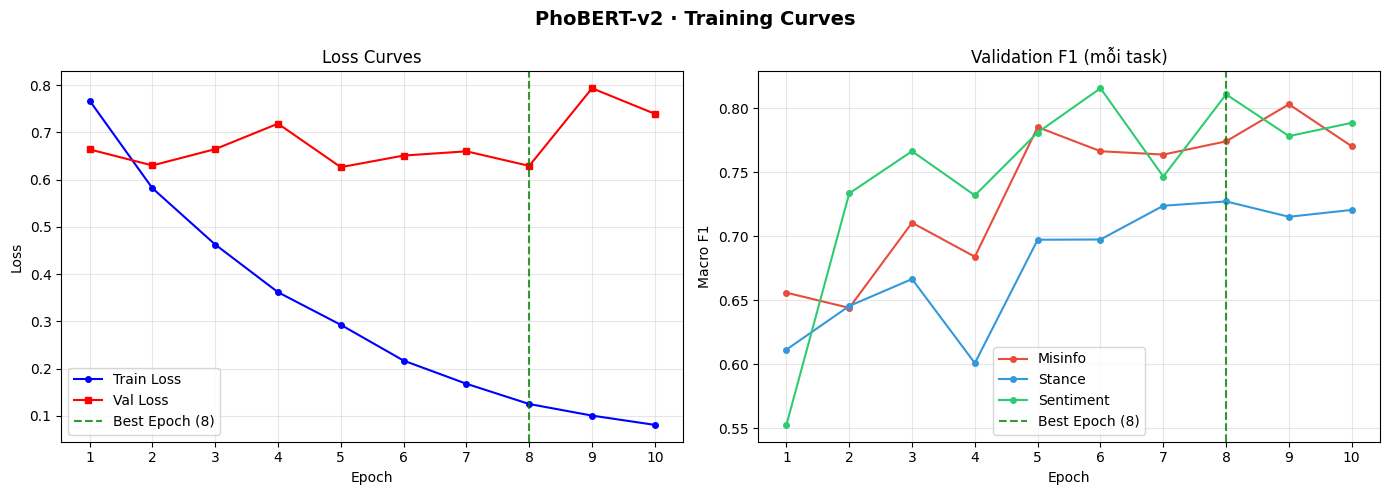

✅ Saved: /kaggle/working/phobert_v2/training_curves.png | Best epoch: 8 (Avg F1 = 0.7709)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PhoBERT-v2 · Training Curves', fontsize=14, fontweight='bold')

# ── Tính best_epoch theo AVG F1 (khớp với tiêu chí lưu model trong training loop) ──
avg_f1_history = [
    np.mean([history[f'f1_{t}'][e] for t in TASKS])
    for e in range(len(history['train_loss']))
]
best_ep = int(np.argmax(avg_f1_history))   # 0-indexed

# Loss curves
ax = axes[0]
epochs_range = range(len(history['train_loss']))
ax.plot(list(epochs_range), history['train_loss'], 'b-o', label='Train Loss', markersize=4)
ax.plot(list(epochs_range), history['val_loss'],   'r-s', label='Val Loss',   markersize=4)
ax.axvline(best_ep, color='green', ls='--', alpha=0.8,
           label=f'Best Epoch ({best_ep + 1})')  # +1 vì x-axis bắt đầu từ 0
ax.set_xticks(list(epochs_range))
ax.set_xticklabels([str(e + 1) for e in epochs_range])  # Hiển thị 1-indexed
ax.set(xlabel='Epoch', ylabel='Loss', title='Loss Curves')
ax.legend(); ax.grid(True, alpha=0.3)

# F1 curves
ax = axes[1]
colors = {'misinfo': '#e74c3c', 'stance': '#3498db', 'sentiment': '#2ecc71'}
for t, c in colors.items():
    ax.plot(list(epochs_range), history[f'f1_{t}'],
            '-o', color=c, label=t.capitalize(), markersize=4)
ax.axvline(best_ep, color='green', ls='--', alpha=0.8, label=f'Best Epoch ({best_ep + 1})')
ax.set_xticks(list(epochs_range))
ax.set_xticklabels([str(e + 1) for e in epochs_range])  # 1-indexed
ax.set(xlabel='Epoch', ylabel='Macro F1', title='Validation F1 (mỗi task)')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/training_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {SAVE_DIR}/training_curves.png | Best epoch: {best_ep + 1} (Avg F1 = {avg_f1_history[best_ep]:.4f})")


## 9. Đánh giá trên Gold Test Set (Benchmark)

> ⚠️ **Tập này hoàn toàn tách biệt khỏi quá trình huấn luyện.**  
> 186 mẫu đã qua Human-in-the-Loop validation — đây là Ground Truth duy nhất cho so sánh mô hình.



In [8]:
# [CELL 12] Final Evaluation (Taxonomy v3)
from sklearn.metrics import classification_report

model.load_state_dict(torch.load(f"{SAVE_DIR}/best_model.pt", map_location=DEVICE))
_, test_f1s, test_preds, test_labels = run_epoch(model, test_loader, train=False)

print("\n" + "="*50 + "\nBENCHMARK - GOLD TEST SET\n" + "="*50)
for t in TASKS:
    print(f"\nTASK: {t.upper()} (F1: {test_f1s[t]:.4f})")
    print(classification_report(test_labels[t], test_preds[t], labels=list(range(N_CLASSES[t])), target_names=HC_NAMES[t], zero_division=0))


Eval:   0%|          | 0/12 [00:00<?, ?it/s]


BENCHMARK - GOLD TEST SET

TASK: MISINFO (F1: 0.6996)
              precision    recall  f1-score   support

     Tin giả       0.44      0.61      0.51        28
   Chính xác       0.93      0.86      0.89       158

    accuracy                           0.82       186
   macro avg       0.68      0.73      0.70       186
weighted avg       0.85      0.82      0.83       186


TASK: STANCE (F1: 0.6640)
              precision    recall  f1-score   support

      Ủng hộ       0.73      0.50      0.59        54
    Phản đối       0.55      0.83      0.66        48
   Trung lập       0.78      0.70      0.74        84

    accuracy                           0.68       186
   macro avg       0.68      0.68      0.66       186
weighted avg       0.70      0.68      0.68       186


TASK: SENTIMENT (F1: 0.7266)
              precision    recall  f1-score   support

    Tiêu cực       0.72      0.90      0.80        71
  Trung tính       0.83      0.76      0.79        75
    Tích cực     

In [9]:
# [CELL 12c] CALIBRATION — Collect logits/probs trên Test Set
# Phục vụ ECE measurement + Temperature Scaling (post-hoc calibration)
import torch
import torch.nn.functional as F

model.load_state_dict(torch.load(f"{SAVE_DIR}/best_model.pt", map_location=DEVICE))
model.eval()

test_logits = {t: [] for t in TASKS}
test_probs  = {t: [] for t in TASKS}
test_y_true = {t: [] for t in TASKS}

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Collecting logits"):
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        logits = model(ids, mask)
        for t in TASKS:
            lg = logits[t].cpu().numpy()      # (B, C)
            pr = F.softmax(logits[t], dim=1).cpu().numpy()  # (B, C)
            test_logits[t].extend(lg.tolist())
            test_probs[t].extend(pr.tolist())
            test_y_true[t].extend(batch[t].numpy().tolist())

# Verify
import numpy as np
for t in TASKS:
    arr = np.array(test_probs[t])
    print(f"{t}: probs shape={arr.shape}, "
          f"mean_max_conf={arr.max(axis=1).mean():.4f}, "
          f"n_samples={len(test_y_true[t])}")
print("✅ Logits/probs collected — ready for calibration analysis")


misinfo: probs shape=(186, 2), mean_max_conf=0.9451, n_samples=186
stance: probs shape=(186, 3), mean_max_conf=0.8675, n_samples=186
sentiment: probs shape=(186, 3), mean_max_conf=0.8887, n_samples=186
✅ Logits/probs collected — ready for calibration analysis


Val logits:   0%|          | 0/11 [00:00<?, ?it/s]


 CALIBRATION ANALYSIS — Guo et al. (ICML 2017)

   Misinfo: T=1.820
             ECE   : 0.1234 → 0.0535  (cải thiện +56.7%)
             Conf  : 94.5% → 87.4%   (Accuracy thật: 82.3%)
             ⚠️ Trung bình

    Stance: T=1.667
             ECE   : 0.1978 → 0.0932  (cải thiện +52.9%)
             Conf  : 86.7% → 76.3%   (Accuracy thật: 67.7%)
             ⚠️ Trung bình

 Sentiment: T=1.347
             ECE   : 0.1438 → 0.0808  (cải thiện +43.8%)
             Conf  : 88.9% → 83.0%   (Accuracy thật: 75.8%)
             ⚠️ Trung bình


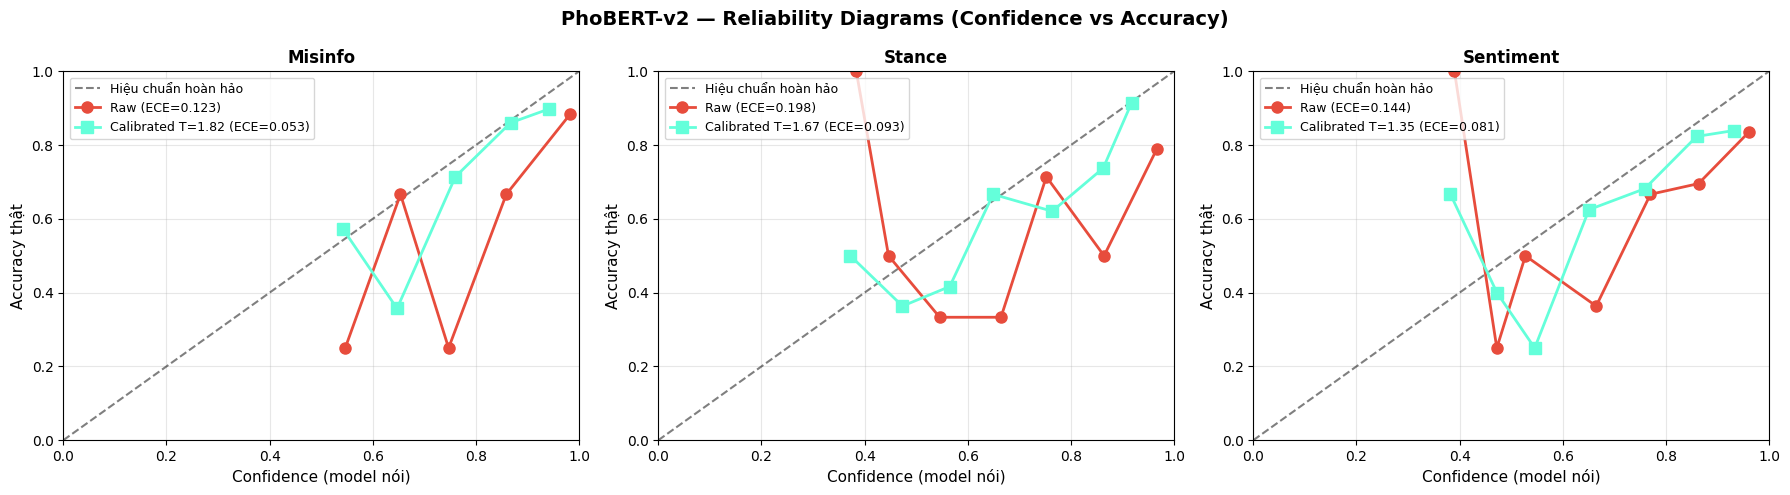


✅ Saved: reliability_diagram.png
✅ Saved: /kaggle/working/temperature_params.json
   App sẽ load T này để hiển thị confidence hiệu chuẩn:
   {
  "misinfo": 1.8197,
  "stance": 1.6666,
  "sentiment": 1.3474
}


In [10]:
# [CELL 12d] CALIBRATION ANALYSIS — ECE + Temperature Scaling
# Đo Expected Calibration Error TRƯỚC vs SAU Temperature Scaling
# Khắc phục Softmax Overconfidence — Guo et al., ICML 2017
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

def expected_calibration_error(y_true, probs, n_bins=10):
    """
    ECE — Expected Calibration Error.
    y_true: (N,) labels
    probs:  (N, C) softmax probabilities
    Trả về: ECE (thấp = hiệu chuẩn tốt; <0.05 tốt, >0.10 nghiêm trọng)
    """
    confidences = probs.max(axis=1)
    predictions = probs.argmax(axis=1)
    accuracies  = (predictions == y_true).astype(float)
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        mask = (confidences > lo) & (confidences <= hi)
        if mask.sum() > 0:
            acc_bin  = accuracies[mask].mean()
            conf_bin = confidences[mask].mean()
            ece += (mask.sum() / len(probs)) * abs(acc_bin - conf_bin)
    return float(ece)

class TemperatureScaler(torch.nn.Module):
    """Học 1 tham số T > 0; logits / T trước softmax."""
    def __init__(self):
        super().__init__()
        self.temperature = torch.nn.Parameter(torch.ones(1) * 1.5)
    def forward(self, logits):
        return logits / self.temperature

def learn_temperature(logits_np, labels_np, max_iter=100):
    """Học T trên (logits, labels) bằng LBFGS minimizing NLL."""
    scaler = TemperatureScaler()
    nll = torch.nn.CrossEntropyLoss()
    logits_t = torch.tensor(logits_np, dtype=torch.float32)
    labels_t = torch.tensor(labels_np, dtype=torch.long)
    optimizer = torch.optim.LBFGS([scaler.temperature], lr=0.01, max_iter=max_iter)
    def closure():
        optimizer.zero_grad()
        loss = nll(scaler(logits_t), labels_t)
        loss.backward()
        return loss
    optimizer.step(closure)
    return float(scaler.temperature.item())

# ── Tính ECE TRƯỚC calibration + học T cho từng task ──
# Lưu ý: T học trên VAL set (val_loader), đo ECE trên TEST set
print("Collecting val logits for T optimization...")
val_logits = {t: [] for t in TASKS}
val_y_true = {t: [] for t in TASKS}
model.eval()
with torch.no_grad():
    for batch in tqdm(val_loader, desc="Val logits"):
        ids, mask = batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE)
        logits = model(ids, mask)
        for t in TASKS:
            val_logits[t].extend(logits[t].cpu().numpy().tolist())
            val_y_true[t].extend(batch[t].numpy().tolist())

calibration_results = {}
temperature_params = {}
HC = {'misinfo': 'Misinfo', 'stance': 'Stance', 'sentiment': 'Sentiment'}

print("\n" + "="*60)
print(" CALIBRATION ANALYSIS — Guo et al. (ICML 2017)")
print("="*60)
for t in TASKS:
    test_probs_t = np.array(test_probs[t])
    y_true_t     = np.array(test_y_true[t])

    # ECE trước
    ece_before = expected_calibration_error(y_true_t, test_probs_t)

    # Học T trên VAL
    T = learn_temperature(np.array(val_logits[t]), np.array(val_y_true[t]))

    # Áp dụng T → softmax mới trên TEST
    test_logits_t = torch.tensor(np.array(test_logits[t]), dtype=torch.float32)
    calibrated_probs = F.softmax(test_logits_t / T, dim=1).numpy()

    # ECE sau
    ece_after = expected_calibration_error(y_true_t, calibrated_probs)

    # Confidence stats
    raw_conf = test_probs_t.max(axis=1).mean()
    cal_conf = calibrated_probs.max(axis=1).mean()
    acc      = (test_probs_t.argmax(axis=1) == y_true_t).mean()

    calibration_results[t] = {
        'temperature': round(T, 4),
        'ece_before':  round(ece_before, 4),
        'ece_after':   round(ece_after, 4),
        'mean_conf_raw':        round(float(raw_conf), 4),
        'mean_conf_calibrated': round(float(cal_conf), 4),
        'accuracy':    round(float(acc), 4),
    }
    temperature_params[t] = round(T, 4)
    print(f"\n{HC[t]:>10}: T={T:.3f}")
    print(f"             ECE   : {ece_before:.4f} → {ece_after:.4f}  "
          f"(cải thiện {(ece_before-ece_after)/max(ece_before,1e-6)*100:+.1f}%)")
    print(f"             Conf  : {raw_conf*100:.1f}% → {cal_conf*100:.1f}%   "
          f"(Accuracy thật: {acc*100:.1f}%)")
    diag = "✅ Hiệu chuẩn TỐT" if ece_after < 0.05 else ("⚠️ Trung bình" if ece_after < 0.10 else "❌ Vẫn lệch")
    print(f"             {diag}")

# ── Reliability Diagram ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('PhoBERT-v2 — Reliability Diagrams (Confidence vs Accuracy)', 
             fontsize=14, fontweight='bold')
for ax, t in zip(axes, TASKS):
    test_probs_t = np.array(test_probs[t])
    y_true_t = np.array(test_y_true[t])
    T = temperature_params[t]
    cal_probs = F.softmax(torch.tensor(np.array(test_logits[t])) / T, dim=1).numpy()

    # Đường lý tưởng
    ax.plot([0,1], [0,1], 'k--', alpha=0.5, label='Hiệu chuẩn hoàn hảo')

    # Trước calibration (max prob → đúng/sai)
    conf_b = test_probs_t.max(axis=1)
    acc_b  = (test_probs_t.argmax(axis=1) == y_true_t).astype(float)
    bins = np.linspace(0, 1, 11)
    idx = np.digitize(conf_b, bins) - 1
    idx = np.clip(idx, 0, 9)
    raw_x, raw_y = [], []
    for b in range(10):
        m = idx == b
        if m.sum() > 0:
            raw_x.append(conf_b[m].mean())
            raw_y.append(acc_b[m].mean())
    ax.plot(raw_x, raw_y, 'o-', color='#e74c3c', linewidth=2, markersize=8,
            label=f'Raw (ECE={calibration_results[t]["ece_before"]:.3f})')

    # Sau calibration
    conf_a = cal_probs.max(axis=1)
    acc_a  = (cal_probs.argmax(axis=1) == y_true_t).astype(float)
    idx_a = np.clip(np.digitize(conf_a, bins) - 1, 0, 9)
    cal_x, cal_y = [], []
    for b in range(10):
        m = idx_a == b
        if m.sum() > 0:
            cal_x.append(conf_a[m].mean())
            cal_y.append(acc_a[m].mean())
    ax.plot(cal_x, cal_y, 's-', color='#64ffda', linewidth=2, markersize=8,
            label=f'Calibrated T={T:.2f} (ECE={calibration_results[t]["ece_after"]:.3f})')

    ax.set_xlabel('Confidence (model nói)', fontsize=11)
    ax.set_ylabel('Accuracy thật', fontsize=11)
    ax.set_title(f'{HC[t]}', fontsize=12, fontweight='bold')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/reliability_diagram.png", dpi=150, bbox_inches='tight')
plt.savefig("/kaggle/working/reliability_diagram.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ Saved: reliability_diagram.png")

# ── Save temperature_params.json (cho streamlit app) ──
import json
with open("/kaggle/working/temperature_params.json", 'w') as f:
    json.dump({"phobert_v2": temperature_params}, f, indent=2)
print(f"✅ Saved: /kaggle/working/temperature_params.json")
print(f"   App sẽ load T này để hiển thị confidence hiệu chuẩn:")
print(f"   {json.dumps(temperature_params, indent=2)}")


In [11]:
# ════════════════════════════════════════════════════════════════════════
# 📑 INTEROP CONTRACT — Schema kết quả đồng nhất giữa 3 model notebooks
# ════════════════════════════════════════════════════════════════════════
# Mỗi notebook model XUẤT 1 file JSON tên DUY NHẤT ở /kaggle/working/ (gốc):
#   PhoBERT → /kaggle/working/phobert_v2_results.json
#   XLM-R   → /kaggle/working/xlmr_v1_results.json
#   Gemma   → /kaggle/working/gemma_v3_results.json
#
# SCHEMA BẮT BUỘC (mọi notebook PHẢI tuân theo):
# {
#   "model":       str,                 # "phobert-v2" | "xlmr-base" | "gemma-4-4b-xai"
#   "timestamp":   str (ISO),
#   "misinfo":   {"macro_f1": float, "per_class": [f1_0, f1_1],          "support": [s0, s1]},
#   "stance":    {"macro_f1": float, "per_class": [f1_0, f1_1, f1_2],    "support": [s0, s1, s2]},
#   "sentiment": {"macro_f1": float, "per_class": [f1_0, f1_1, f1_2],    "support": [s0, s1, s2]}
# }
# Taxonomy v3: Misinfo(2) Stance(3) Sentiment(3)
# ════════════════════════════════════════════════════════════════════════

# [CELL 12b] Export — schema chuẩn INTEROP
import datetime, json, os

def _per_class_f1_support(y_true, y_pred, n_classes):
    from sklearn.metrics import f1_score as _f1
    f1s, sups = [], []
    for c in range(n_classes):
        yt = [1 if y==c else 0 for y in y_true]
        yp = [1 if y==c else 0 for y in y_pred]
        f1s.append(round(_f1(yt, yp, zero_division=0), 4))
        sups.append(int(sum(yt)))
    return f1s, sups

phobert_results = {
    'model':            'phobert-v2',
    'timestamp':        datetime.datetime.now().isoformat(),
    'val_loss_best':    round(float(best_val_loss), 4),
    'training_seconds': training_seconds,
}
for t in TASKS:
    f1s, sups = _per_class_f1_support(test_labels[t], test_preds[t], N_CLASSES[t])
    phobert_results[t] = {'macro_f1': round(test_f1s[t], 4),
                          'per_class': f1s, 'support': sups,
                          # CALIBRATION DATA — for ECE + Temperature Scaling
                          'logits':      test_logits[t],
                          'probs':       test_probs[t],
                          'true_labels': test_y_true[t]}

# Thêm calibration metrics nếu Cell 12d đã chạy
try:
    phobert_results['calibration'] = calibration_results
    phobert_results['temperature'] = temperature_params
except NameError:
    pass  # Cell calibration chưa chạy — skip

# Save BOTH to model dir (archive) AND /kaggle/working root (interop discovery)
os.makedirs(SAVE_DIR, exist_ok=True)
for _p in [f"{SAVE_DIR}/phobert_v2_results.json",
           "/kaggle/working/phobert_v2_results.json"]:
    with open(_p, 'w', encoding='utf-8') as f:
        json.dump(phobert_results, f, indent=2, ensure_ascii=False)

# Schema validation
for t in TASKS:
    assert len(phobert_results[t]['per_class']) == N_CLASSES[t], f'per_class len: {t}'
    assert len(phobert_results[t]['support'])   == N_CLASSES[t], f'support len: {t}'

print("✅ INTEROP JSON saved:")
print("   /kaggle/working/phobert_v2_results.json")
print(json.dumps(phobert_results, indent=2, ensure_ascii=False))


✅ INTEROP JSON saved:
   /kaggle/working/phobert_v2_results.json
{
  "model": "phobert-v2",
  "timestamp": "2026-05-20T23:39:09.478199",
  "val_loss_best": 0.629,
  "training_seconds": 710,
  "misinfo": {
    "macro_f1": 0.6996,
    "per_class": [
      0.5075,
      0.8918
    ],
    "support": [
      28,
      158
    ],
    "logits": [
      [
        -2.991507053375244,
        3.144134283065796
      ],
      [
        -2.1692123413085938,
        2.0698516368865967
      ],
      [
        -2.437553882598877,
        2.6573455333709717
      ],
      [
        -2.210115671157837,
        2.541330337524414
      ],
      [
        -0.4245602786540985,
        0.46201983094215393
      ],
      [
        -1.957208275794983,
        1.809482455253601
      ],
      [
        2.822521448135376,
        -3.0812366008758545
      ],
      [
        2.276810646057129,
        -2.4990217685699463
      ],
      [
        -2.374102830886841,
        2.1004483699798584
      ],
      [
  

## 10. Xuất Kết quả — Định dạng đồng bộ với Gemma

File `benchmark_results.json` được xuất với cấu trúc **đồng bộ 100%** với file kết quả của Gemma-4,  
để đảm bảo script so sánh mô hình chạy được mà không cần chỉnh sửa.


## 11. Confusion Matrix — Phân tích Lỗi Trực quan

Confusion matrix trên Gold Test Set giúp xác định:
- Nhãn nào model hay nhầm lẫn nhất?
- False Negative quan trọng: Model bỏ sót *Tin giả* → phân loại thành *Chính xác*?


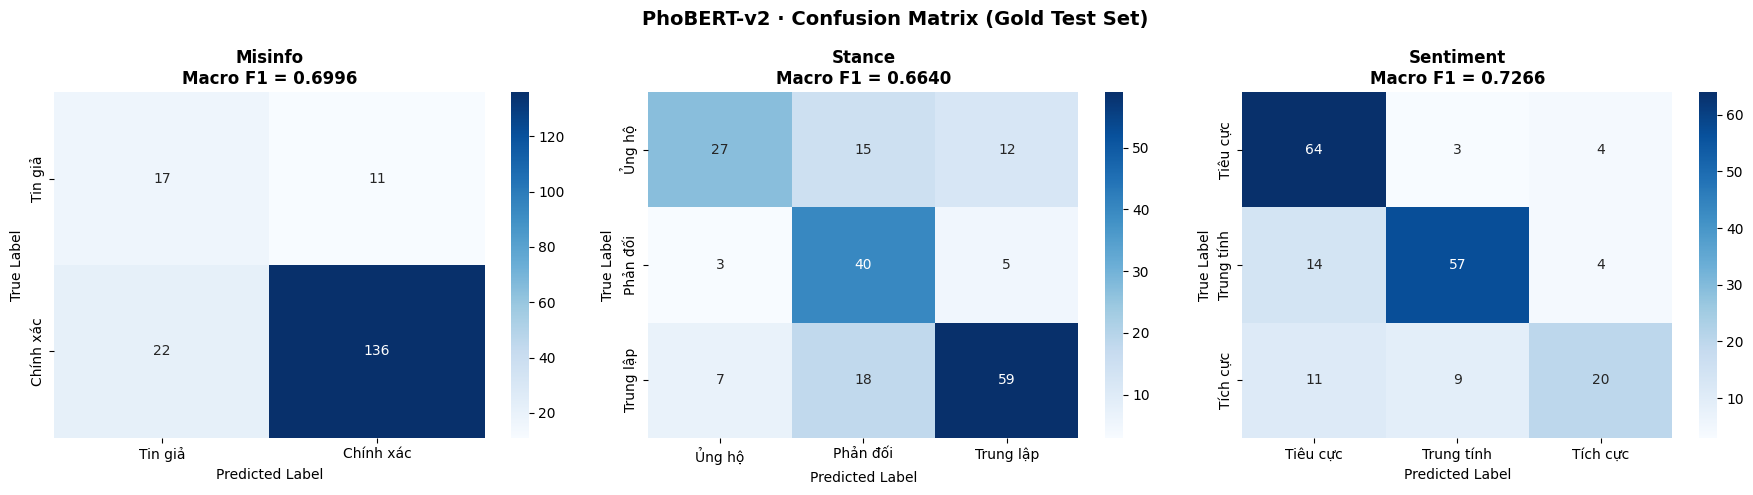

✅ Saved: /kaggle/working/phobert_v2/confusion_matrices.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('PhoBERT-v2 · Confusion Matrix (Gold Test Set)', fontsize=14, fontweight='bold')

for i, t in enumerate(TASKS):
    present = sorted(set(test_labels[t]) | set(test_preds[t]))
    cm      = confusion_matrix(test_labels[t], test_preds[t], labels=present)
    names   = [LABEL_NAMES[t][j] for j in present if j < len(LABEL_NAMES[t])]
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        ax=axes[i], xticklabels=names, yticklabels=names
    )
    axes[i].set_title(f'{t.capitalize()}\nMacro F1 = {test_f1s[t]:.4f}', fontweight='bold')
    axes[i].set_ylabel('True Label')
    axes[i].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {SAVE_DIR}/confusion_matrices.png")


## 12. (Tùy chọn) Upload lên Hugging Face Hub

Model đã được public tại: [hung2903/phobert-vaccine-multitask](https://huggingface.co/hung2903/phobert-vaccine-multitask)


In [13]:
# (Tùy chọn) Upload lên Hugging Face Hub
try:
    from huggingface_hub import login, HfApi
    from kaggle_secrets import UserSecretsClient
    user_secrets = UserSecretsClient()
    HF_TOKEN = user_secrets.get_secret("HF_TOKEN")

    login(token=HF_TOKEN)
    api = HfApi()
    api.upload_folder(
        folder_path=SAVE_DIR,
        repo_id="hung2903/phobert-vaccine-multitask",
        repo_type="model",
    )
    print("✅ Uploaded to HuggingFace!")
except Exception as e:
    print(f"⚠️  HF upload failed (non-fatal): {e}")

print("✅ Notebook hoàn tất!")
print(f"   Model weights : {SAVE_DIR}/best_model.pt")
print(f"   Results JSON  : {SAVE_DIR}/benchmark_results.json")
print(f"   Training plot : {SAVE_DIR}/training_curves.png")
print(f"   Confusion mat : {SAVE_DIR}/confusion_matrices.png")


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

✅ Uploaded to HuggingFace!
✅ Notebook hoàn tất!
   Model weights : /kaggle/working/phobert_v2/best_model.pt
   Results JSON  : /kaggle/working/phobert_v2/benchmark_results.json
   Training plot : /kaggle/working/phobert_v2/training_curves.png
   Confusion mat : /kaggle/working/phobert_v2/confusion_matrices.png


In [14]:
# [CELL 12] Final Evaluation (Taxonomy v3)
from sklearn.metrics import classification_report, f1_score

def run_evaluation(model, loader, title="Evaluation"):
    model.eval()
    all_labels = {t: [] for t in TASKS}
    all_preds  = {t: [] for t in TASKS}
    
    with torch.no_grad():
        for batch in tqdm(loader, desc=title):
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            
            outputs = model(input_ids, attention_mask)
            
            for t in TASKS:
                all_labels[t].extend(batch[t].numpy())
                all_preds[t].extend(torch.argmax(outputs[t], dim=1).cpu().numpy())
    
    print(f"\n=== {title} Report ===")
    for t in TASKS:
        print(f"\nTask: {t.upper()}")
        print(classification_report(all_labels[t], all_preds[t], 
                                    labels=list(range(N_CLASSES[t])),
                                    zero_division=0))
        f1 = f1_score(all_labels[t], all_preds[t], average='macro', 
                      labels=list(range(N_CLASSES[t])), zero_division=0)
        print(f"Macro F1: {f1:.4f}")

# Run on Test Set
run_evaluation(model, test_loader, title="Gold Test Set (v3)")


Gold Test Set (v3):   0%|          | 0/12 [00:00<?, ?it/s]


=== Gold Test Set (v3) Report ===

Task: MISINFO
              precision    recall  f1-score   support

           0       0.44      0.61      0.51        28
           1       0.93      0.86      0.89       158

    accuracy                           0.82       186
   macro avg       0.68      0.73      0.70       186
weighted avg       0.85      0.82      0.83       186

Macro F1: 0.6996

Task: STANCE
              precision    recall  f1-score   support

           0       0.73      0.50      0.59        54
           1       0.55      0.83      0.66        48
           2       0.78      0.70      0.74        84

    accuracy                           0.68       186
   macro avg       0.68      0.68      0.66       186
weighted avg       0.70      0.68      0.68       186

Macro F1: 0.6640

Task: SENTIMENT
              precision    recall  f1-score   support

           0       0.72      0.90      0.80        71
           1       0.83      0.76      0.79        75
           2  